# Modèle 4 — Quels dégâts ?

Ce notebook sert à construire un modèle de classification capable d'estimer le niveau de dommages d'un séisme.

La variable cible est `Damage_Level` avec trois classes : `Faible`, `Modéré` et `Sévère`.

Les classes sont construites à partir des informations USGS PAGER afin d'éviter de définir les dommages directement à partir de la magnitude.

### 1. Import des bibliothèques

Je commence par importer les bibliothèques dont j'ai besoin pour manipuler les données, faire les calculs, créer les graphiques et récupérer les informations USGS.

In [1]:
# ============================================================
# MODÈLE 4 — QUELS DÉGÂTS ?
# Classification du niveau de dommages
# ============================================================

import os
import requests
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


**Interprétation du résultat :**  
Le chargement s'est bien passé. Les bibliothèques nécessaires sont maintenant prêtes pour la suite du notebook.

### 2. Chargement du fichier de travail

Je charge mon propre fichier `usgs_damage_2025.csv`. Le fichier source partagé reste intact et je travaille seulement sur cette copie pour le modèle Damage.

In [2]:
# ============================================================
# CHARGEMENT DU DATASET DAMAGE
# ============================================================

file_path = os.path.join("..", "data", "usgs_damage_2025.csv")

df = pd.read_csv(file_path)

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

display(df.head())

Nombre de lignes : 29062
Nombre de colonnes : 35


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


**Interprétation du résultat :**  
Le fichier contient **29 062 séismes et 35 colonnes**. Le dataset est bien chargé et peut être analysé.

### 3. Vérification des variables d'impact

Je regarde les variables qui peuvent être utiles pour mesurer les effets d'un séisme et je vérifie combien de valeurs sont manquantes.

In [3]:
# ============================================================
# VÉRIFICATION DES VARIABLES D'IMPACT
# ============================================================

impact_variables = [
    'mag',
    'depth',
    'mmi',
    'cdi',
    'felt',
    'alert',
    'sig',
    'tsunami',
    'latitude',
    'longitude'
]

missing_impact = pd.DataFrame({
    'Valeurs_manquantes': df[impact_variables].isnull().sum(),
    'Pourcentage': (df[impact_variables].isnull().mean() * 100).round(2)
})

display(missing_impact)

,Valeurs_manquantes,Pourcentage
mag,0,0.00
depth,0,0.00
mmi,27072,93.15
cdi,25185,86.66
felt,25185,86.66
alert,28158,96.89
sig,0,0.00
tsunami,0,0.00
latitude,0,0.00
longitude,0,0.00


**Interprétation du résultat :**  
Certaines variables sont complètes, comme `mag`, `depth`, `sig`, `tsunami`, `latitude` et `longitude`. Par contre, `mmi`, `cdi`, `felt` et surtout `alert` contiennent beaucoup de valeurs manquantes.

### 4. Vérification des identifiants USGS

Je vérifie que chaque séisme possède un `event_id` unique. Cet identifiant permet ensuite d'aller chercher les produits détaillés de l'événement dans USGS.

In [4]:
# ============================================================
# VÉRIFICATION DES EVENT_ID
# ============================================================

print("Nombre total de lignes :", len(df))
print("Nombre d'event_id non nuls :", df['event_id'].notna().sum())
print("Nombre d'event_id uniques :", df['event_id'].nunique())

display(df[['event_id', 'mag', 'place']].head(10))

Nombre total de lignes : 29062
Nombre d'event_id non nuls : 29062
Nombre d'event_id uniques : 29062


,event_id,mag,place
0,us7000q9mu,4.20,"70 km W of Abra Pampa, Argentina"
1,us7000qb5r,2.50,"1 km E of Nikolski, Alaska"
2,us7000qb5v,2.80,"31 km SSE of Nikolski, Alaska"
3,us7000q9mt,3.80,"153 km S of Nikolski, Alaska"
4,us7000q9mq,4.50,"185 km WSW of Tual, Indonesia"
5,us7000q9mr,4.50,Carlsberg Ridge
6,pr71487608,2.64,"5 km S of Guánica, Puerto Rico"
7,us7000qbub,4.50,"113 km WNW of Malango, Solomon Islands"
8,us7000q9mh,4.50,Carlsberg Ridge
9,us7000q9mg,4.50,south of the Fiji Islands


**Interprétation du résultat :**  
Les **29 062 événements possèdent un identifiant unique**. On peut donc utiliser `event_id` pour récupérer les informations détaillées de chaque séisme.

### 5. Vérification des liens de détail USGS

Chaque événement contient aussi un lien `detail`. Je vérifie que ces liens sont disponibles avant de récupérer les produits PAGER et ShakeMap.

In [5]:
# ============================================================
# VÉRIFICATION DES LIENS DETAIL
# ============================================================

print("Nombre de liens detail disponibles :")
print(df['detail'].notna().sum())

display(df[['event_id', 'detail']].head())

Nombre de liens detail disponibles :
29062


,event_id,detail
0,us7000q9mu,https://earthquake.usgs.gov/fdsnws/event/1/que...
1,us7000qb5r,https://earthquake.usgs.gov/fdsnws/event/1/que...
2,us7000qb5v,https://earthquake.usgs.gov/fdsnws/event/1/que...
3,us7000q9mt,https://earthquake.usgs.gov/fdsnws/event/1/que...
4,us7000q9mq,https://earthquake.usgs.gov/fdsnws/event/1/que...


**Interprétation du résultat :**  
Les **29 062 événements possèdent un lien `detail`**. Ces liens permettent d'interroger directement les détails USGS.

### 6. Test d'un premier événement USGS

Je commence par un seul séisme pour vérifier que l'URL fonctionne et que l'API USGS retourne bien un objet GeoJSON.

In [6]:
# ============================================================
# TEST SUR UN SEUL ÉVÉNEMENT USGS
# ============================================================

detail_url = df.loc[0, 'detail']

print("URL test :")
print(detail_url)

response = requests.get(detail_url, timeout=30)
response.raise_for_status()

print("\nCode HTTP :", response.status_code)

event_detail = response.json()

print("\nClés principales :")
print(event_detail.keys())

URL test :
https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=us7000q9mu&format=geojson

Code HTTP : 200

Clés principales :
dict_keys(['type', 'properties', 'geometry', 'id'])


**Interprétation du résultat :**  
La requête USGS fonctionne correctement avec un code HTTP **200**. Le résultat contient les informations principales de l'événement dans un objet GeoJSON.

### 7. Produits disponibles pour le premier événement

Je regarde les produits USGS liés à ce séisme. Tous les événements n'ont pas forcément PAGER ou ShakeMap.

In [7]:
# ============================================================
# PRODUITS USGS DISPONIBLES POUR CET ÉVÉNEMENT
# ============================================================

products = event_detail.get('properties', {}).get('products', {})

print("Produits disponibles :")
print(products.keys())

Produits disponibles :
dict_keys(['origin', 'phase-data'])


**Interprétation du résultat :**  
Le premier événement ne contient que `origin` et `phase-data`. Il ne possède donc pas de produit PAGER ou ShakeMap.

### 8. Choix d'un événement avec une alerte PAGER

Comme le premier événement ne contient pas PAGER, je sélectionne un séisme qui possède déjà une valeur `alert`.

In [8]:
# ============================================================
# CHOISIR UN ÉVÉNEMENT AVEC ALERT DISPONIBLE
# ============================================================

event_with_alert = df[df['alert'].notna()].iloc[0]

print("event_id :", event_with_alert['event_id'])
print("magnitude :", event_with_alert['mag'])
print("alert :", event_with_alert['alert'])
print("detail :", event_with_alert['detail'])

event_id : nc75202001
magnitude : 4.54
alert : green
detail : https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=nc75202001&format=geojson


**Interprétation du résultat :**  
J'ai choisi un événement qui possède une alerte PAGER. Il servira à vérifier les produits d'impact disponibles dans USGS.

### 9. Récupération des produits de l'événement avec alerte

Je récupère les détails de cet événement et je vérifie si `losspager` et `shakemap` sont présents.

In [9]:
# ============================================================
# RÉCUPÉRER LES PRODUITS USGS POUR L'ÉVÉNEMENT AVEC ALERT
# ============================================================

detail_url_alert = event_with_alert['detail']

response_alert = requests.get(detail_url_alert, timeout=30)
response_alert.raise_for_status()

event_detail_alert = response_alert.json()

products_alert = event_detail_alert.get(
    'properties',
    {}
).get(
    'products',
    {}
)

print("Produits disponibles :")
print(products_alert.keys())

Produits disponibles :
dict_keys(['dyfi', 'event-sequence', 'focal-mechanism', 'losspager', 'moment-tensor', 'nearby-cities', 'oaf', 'origin', 'phase-data', 'scitech-link', 'shake-alert', 'shakemap'])


**Interprétation du résultat :**  
Cet événement contient bien `losspager` et `shakemap`. On peut donc utiliser les données PAGER pour étudier les impacts du séisme.

### 10. Lecture des propriétés LossPAGER

Je regarde les propriétés principales de LossPAGER. On y trouve notamment le niveau d'alerte et le MMI maximum.

In [10]:
# ============================================================
# EXAMINER LE PRODUIT LOSSPAGER
# ============================================================

losspager = products_alert['losspager']

print("Nombre de produits LossPAGER :", len(losspager))

print("\nPropriétés disponibles :")
print(losspager[0]['properties'])

Nombre de produits LossPAGER : 1

Propriétés disponibles :
{'alertlevel': 'green', 'depth': '10.0', 'eventsource': 'us', 'eventsourcecode': '7000q9g4', 'eventtime': '2025-06-29T02:37:57.000Z', 'latitude': '37.3199', 'longitude': '-117.8978', 'magnitude': '4.5', 'maxmmi': '3', 'pdl-client-version': 'Version 2.7.9 2021-02-10', 'review-status': 'automatic'}


**Interprétation du résultat :**  
LossPAGER fournit notamment `alertlevel`, `maxmmi`, la magnitude, la profondeur et d'autres informations utiles pour caractériser l'impact.

### 11. Liste des fichiers LossPAGER

Je regarde les fichiers disponibles dans LossPAGER pour savoir où trouver les informations sur les pertes, l'exposition et les alertes.

In [11]:
# ============================================================
# FICHIERS DISPONIBLES DANS LOSSPAGER
# ============================================================

contents = losspager[0].get('contents', {})

print("Nombre de fichiers disponibles :", len(contents))

print("\nFichiers LossPAGER :")
for file_name in contents.keys():
    print(file_name)

Nombre de fichiers disponibles : 23

Fichiers LossPAGER :
json/cities.json
onepager.pdf
alertecon.png
json/comments.json
exposure.png
alertfatal_small.png
json/alerts.json
json/exposures.json
json/historical_earthquakes.json
alertecon.pdf
grid.xml
onepager.aux
contents.xml
exposure.pdf
json/losses.json
alertfatal.pdf
alertfatal_smaller.png
json/event.json
onepager.tex
pager.xml
alertecon_small.png
alertecon_smaller.png
alertfatal.png


**Interprétation du résultat :**  
LossPAGER contient plusieurs fichiers utiles, dont `alerts.json`, `losses.json`, `exposures.json` et `pager.xml`.

### 12. Vérification du fichier `losses.json`

Je récupère les informations du fichier `losses.json`, qui contient les estimations de pertes humaines et économiques.

In [12]:
# ============================================================
# EXAMINER LE FICHIER JSON DES PERTES
# ============================================================

losses_info = contents.get('json/losses.json')

print(losses_info)

{'contentType': 'application/json', 'lastModified': 1753238044000, 'length': 1762, 'url': 'https://earthquake.usgs.gov/product/losspager/us7000q9g4/us/1753238045748/json/losses.json', 'sha256': 'Nw+/HQ4SICOtSuFf5EEa6RISzLzeK+3uTvkLYSSr7nY='}


**Interprétation du résultat :**  
Le fichier `losses.json` est disponible en ligne. Son URL peut être utilisée pour lire les estimations de pertes.

### 13. Lecture des pertes du premier événement PAGER

Je lis le contenu réel de `losses.json` pour voir les informations d'impact disponibles.

In [13]:
# ============================================================
# LIRE LES DONNÉES DE PERTES LOSSPAGER
# ============================================================

losses_url = losses_info['url']

response_losses = requests.get(losses_url, timeout=30)
response_losses.raise_for_status()

losses_data = response_losses.json()

print("Contenu de losses.json :")
print(losses_data)

Contenu de losses.json :
{'empirical_fatality': {'total_fatalities': 0, 'country_fatalities': [{'country_code': 'XF', 'rates': [3.5585648867877515e-24, 1.7969592958387026e-16, 1.060587335234424e-12, 2.3635331782477097e-10, 1.0195911833251078e-08, 1.6744851589378776e-07, 1.4706793235311125e-06, 8.375758672617412e-06, 3.483205281028768e-05, 0.00011433530742831048], 'fatalities': 0}, {'country_code': 'WU', 'rates': [3.5585648867877515e-24, 1.7969592958387026e-16, 1.060587335234424e-12, 2.3635331782477097e-10, 1.0195911833251078e-08, 1.6744851589378776e-07, 1.4706793235311125e-06, 8.375758672617412e-06, 3.483205281028768e-05, 0.00011433530742831048], 'fatalities': 0}]}, 'empirical_economic': {'total_dollars': 0, 'country_dollars': [{'country_code': 'XF', 'rates': [3.175040279587144e-113, 1.4250618650365945e-55, 1.8365545035346508e-31, 1.2035051313071016e-18, 3.819280386801012e-11, 1.3898112957263193e-06, 0.0008254487159486982, 0.03491531325184238, 0.2622077498806025, 0.6612291524798904], '

**Interprétation du résultat :**  
Pour cet événement vert, les estimations de pertes humaines et économiques sont nulles. Cela correspond à un impact faible.

### 14. Recherche d'événements avec une alerte plus élevée

Je cherche ensuite des séismes `yellow`, `orange` ou `red` pour comparer les cas plus importants avec les événements `green`.

In [14]:
# ============================================================
# TROUVER DES ÉVÉNEMENTS AVEC IMPACT PLUS IMPORTANT
# ============================================================

display(
    df[df['alert'].isin(['yellow', 'orange', 'red'])][
        ['event_id', 'mag', 'mmi', 'alert', 'place']
    ].head(10)
)

,event_id,mag,mmi,alert,place
1018,us6000qkg7,5.6,5.748,yellow,"37 km WSW of Callao, Peru"
1434,us6000qixr,6.3,8.272,yellow,"15 km NE of Paratebueno, Colombia"
1575,us6000qigd,6.4,7.031,yellow,"45 km SW of Diego de Almagro, Chile"
2590,us7000q0pq,6.2,6.849,yellow,"66 km SE of Emporeío, Greece"
3189,us7000pyq7,5.5,7.955,yellow,"126 km W of Rikaze, China"
4363,us7000pv06,6.3,7.420,yellow,"19 km NE of Esmeraldas, Ecuador"
4472,us7000pufs,6.2,8.039,orange,"24 km SE of Marmara Ereğlisi, Turkey"
5162,us6000q5q8,5.8,7.896,yellow,"42 km ESE of Rasht, Tajikistan"
5168,us6000q5ps,5.3,8.086,orange,"41 km S of Kyaukse, Burma (Myanmar)"
6380,us7000pn9z,6.7,8.978,red,Burma (Myanmar)


**Interprétation du résultat :**  
Cette sélection permet de repérer des événements avec un niveau d'impact plus élevé afin de comparer les cas faibles et sévères.

### 15. Test d'un événement PAGER rouge

Je sélectionne un événement `red` afin de vérifier les produits disponibles pour un séisme à impact important.

In [15]:
# ============================================================
# TEST D'UN ÉVÉNEMENT AVEC ALERTE ROUGE
# ============================================================

red_event = df[df['alert'] == 'red'].iloc[0]

print("event_id :", red_event['event_id'])
print("magnitude :", red_event['mag'])
print("MMI :", red_event['mmi'])
print("alert :", red_event['alert'])
print("place :", red_event['place'])

response_red = requests.get(red_event['detail'], timeout=30)
response_red.raise_for_status()

red_detail = response_red.json()

red_products = red_detail.get('properties', {}).get('products', {})

print("\nProduits disponibles :")
print(red_products.keys())

event_id : us7000pn9z
magnitude : 6.7
MMI : 8.978
alert : red
place : Burma (Myanmar)

Produits disponibles :
dict_keys(['dyfi', 'earthquake-name', 'ground-failure', 'impact-text', 'losspager', 'moment-tensor', 'origin', 'phase-data', 'shakemap'])


**Interprétation du résultat :**  
Un événement `red` a été trouvé. Il possède aussi `losspager` et `shakemap`, ce qui permet d'examiner un cas sévère.

### 16. Lecture des pertes du séisme rouge

Je récupère les pertes estimées pour ce séisme rouge. Cela permet de confirmer que PAGER contient des données d'impact réelles et pas seulement la magnitude.

In [16]:
# ============================================================
# LIRE LES PERTES LOSSPAGER DE L'ÉVÉNEMENT ROUGE
# ============================================================

red_losspager = red_products['losspager'][0]
red_contents = red_losspager.get('contents', {})

red_losses_url = red_contents['json/losses.json']['url']

response_red_losses = requests.get(red_losses_url, timeout=30)
response_red_losses.raise_for_status()

red_losses = response_red_losses.json()

fatalities = red_losses.get(
    'empirical_fatality', {}
).get('total_fatalities')

economic_loss = red_losses.get(
    'empirical_economic', {}
).get('total_dollars')

print("Pertes estimées pour le séisme rouge")
print("-------------------------------------")
print("Fatalités :", fatalities)
print("Pertes économiques ($) :", economic_loss)

Pertes estimées pour le séisme rouge
-------------------------------------
Fatalités : 1004
Pertes économiques ($) : 1083286491


**Interprétation du résultat :**  
Pour ce séisme rouge, PAGER estime environ **1 004 fatalités** et plus de **1 milliard de dollars de pertes économiques**. Cela confirme qu'il s'agit d'un cas d'impact important.

### 17. Lecture du fichier `alerts.json`

Je regarde les niveaux d'alerte PAGER pour les pertes humaines et économiques. Cela confirme les catégories `green`, `yellow`, `orange` et `red`.

In [17]:
# ============================================================
# EXAMINER ALERTS.JSON DU SÉISME ROUGE
# ============================================================

red_alerts_url = red_contents['json/alerts.json']['url']

response_red_alerts = requests.get(red_alerts_url, timeout=30)
response_red_alerts.raise_for_status()

red_alerts = response_red_alerts.json()

print("Contenu de alerts.json :")
print(red_alerts)

Contenu de alerts.json :
{'fatality': {'type': 'fatality', 'units': 'fatalities', 'gvalue': 2.5, 'summary': False, 'level': 'red', 'bins': [{'color': 'green', 'min': '0', 'max': '1', 'probability': 0.0028488027316064986}, {'color': 'yellow', 'min': '1', 'max': '10', 'probability': 0.029767223070987166}, {'color': 'yellow', 'min': '10', 'max': '100', 'probability': 0.14548379126532393}, {'color': 'orange', 'min': '100', 'max': '1000', 'probability': 0.32126314878160045}, {'color': 'red', 'min': '1000', 'max': '10000', 'probability': 0.321703571100078}, {'color': 'red', 'min': '10000', 'max': '100000', 'probability': 0.14608392323282393}, {'color': 'red', 'min': '100000', 'max': '10000000', 'probability': 0.0328495398174945}]}, 'economic': {'type': 'economic', 'units': 'USD', 'gvalue': 2.5, 'summary': True, 'level': 'red', 'bins': [{'color': 'green', 'min': '0', 'max': '1', 'probability': 0.002594200010213441}, {'color': 'yellow', 'min': '1', 'max': '10', 'probability': 0.027866363456981

**Interprétation du résultat :**  
PAGER classe les impacts selon les niveaux `green`, `yellow`, `orange` et `red`. Ces niveaux seront utilisés pour construire notre variable cible.

### 18. Distribution des alertes PAGER dans le dataset

Je compte les événements disponibles dans chaque niveau PAGER. Cela permet de voir immédiatement si les classes sont équilibrées.

In [18]:
# ============================================================
# DISTRIBUTION DES NIVEAUX D'ALERTE PAGER
# ============================================================

alert_counts = df['alert'].value_counts(dropna=False)

print("Distribution de alert :")
print(alert_counts)

print("\nPourcentage :")
print(
    (df['alert'].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
)

Distribution de alert :
alert
NaN       28158
green       865
yellow       25
orange        7
red           7
Name: count, dtype: int64

Pourcentage :
alert
NaN       96.89
green      2.98
yellow     0.09
orange     0.02
red        0.02
Name: proportion, dtype: float64


**Interprétation du résultat :**  
La plupart des événements n'ont pas d'alerte PAGER. Parmi les **904 événements disponibles**, la grande majorité est `green`, ce qui montre déjà un fort déséquilibre.

### 19. Création du sous-ensemble PAGER

Je garde les événements qui possèdent une alerte PAGER et je vérifie les valeurs manquantes dans les variables candidates.

In [19]:
# ============================================================
# VÉRIFIER LES DONNÉES POUR LES ÉVÉNEMENTS AVEC PAGER
# ============================================================

df_pager = df[df['alert'].notna()].copy()

print("Nombre d'événements PAGER :", len(df_pager))

variables = [
    'mag',
    'depth',
    'mmi',
    'cdi',
    'felt',
    'sig',
    'tsunami',
    'latitude',
    'longitude'
]

print("\nValeurs manquantes :")
print(df_pager[variables].isnull().sum())

Nombre d'événements PAGER : 904

Valeurs manquantes :
mag            0
depth          0
mmi            0
cdi          451
felt         451
sig            0
tsunami        0
latitude       0
longitude      0
dtype: int64


**Interprétation du résultat :**  
Le sous-ensemble PAGER contient **904 événements**. Les variables principales sont complètes, sauf `cdi` et `felt`, qui ont 451 valeurs manquantes.

### 20. Création de la variable cible `Damage_Level`

Je transforme les quatre niveaux PAGER en trois classes pour le modèle : `green` devient `Faible`, `yellow` devient `Modéré`, et `orange` ou `red` deviennent `Sévère`.

La cible n'est donc pas créée à partir de la magnitude.

In [20]:
# ============================================================
# CRÉATION DE LA VARIABLE CIBLE Y : Damage_Level
# ============================================================

damage_mapping = {
    'green': 'Faible',
    'yellow': 'Modéré',
    'orange': 'Sévère',
    'red': 'Sévère'
}

df_pager['Damage_Level'] = df_pager['alert'].map(damage_mapping)

print("Distribution de la variable cible Y :")
print(df_pager['Damage_Level'].value_counts())

print("\nPourcentage :")
print(
    (df_pager['Damage_Level'].value_counts(normalize=True) * 100)
    .round(2)
)

Distribution de la variable cible Y :
Damage_Level
Faible    865
Modéré     25
Sévère     14
Name: count, dtype: int64

Pourcentage :
Damage_Level
Faible    95.69
Modéré     2.77
Sévère     1.55
Name: proportion, dtype: float64


**Interprétation du résultat :**  
La variable cible contient **865 Faible, 25 Modéré et 14 Sévère**. Les classes sont donc très déséquilibrées.

### 21. Visualisation de la variable cible

Je trace la distribution des trois classes. Le graphique montre clairement que la classe `Faible` est beaucoup plus présente que `Modéré` et `Sévère`.

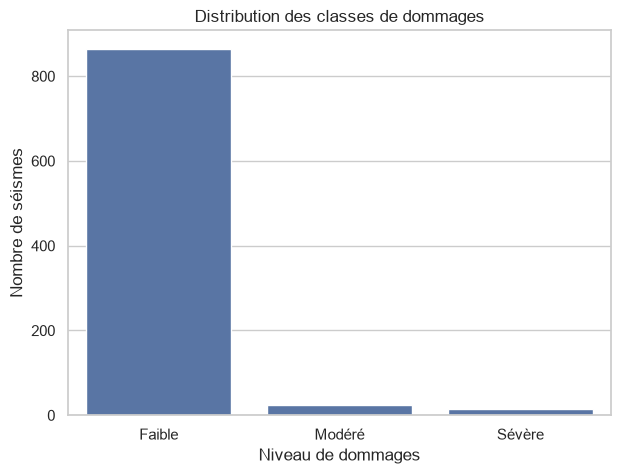

In [21]:
# ============================================================
# VISUALISATION DE LA VARIABLE CIBLE Y
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_pager,
    x='Damage_Level',
    order=['Faible', 'Modéré', 'Sévère']
)

plt.title("Distribution des classes de dommages")
plt.xlabel("Niveau de dommages")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**  
Le graphique confirme visuellement que la classe `Faible` domine largement les deux autres classes.

### 22. Choix des variables candidates pour X

Je prépare les variables qui peuvent servir à prédire le niveau de dommages. Je n'utilise pas `alert` dans X, car `Damage_Level` a été construit à partir de cette variable.

In [22]:
# ============================================================
# VARIABLES CANDIDATES POUR X
# ============================================================

x_candidates = [
    'mag',
    'depth',
    'mmi',
    'cdi',
    'felt',
    'sig',
    'tsunami',
    'latitude',
    'longitude'
]

print("Variables candidates pour X :")
print(x_candidates)

print("\nTypes des variables :")
print(df_pager[x_candidates].dtypes)

print("\nValeurs manquantes :")
print(df_pager[x_candidates].isnull().sum())

Variables candidates pour X :
['mag', 'depth', 'mmi', 'cdi', 'felt', 'sig', 'tsunami', 'latitude', 'longitude']

Types des variables :
mag          float64
depth        float64
mmi          float64
cdi          float64
felt         float64
sig            int64
tsunami        int64
latitude     float64
longitude    float64
dtype: object

Valeurs manquantes :
mag            0
depth          0
mmi            0
cdi          451
felt         451
sig            0
tsunami        0
latitude       0
longitude      0
dtype: int64


**Interprétation du résultat :**  
Les neuf variables candidates sont numériques. `cdi` et `felt` sont les seules à avoir encore des valeurs manquantes.

### 23. Valeurs manquantes par classe

Je vérifie si les valeurs manquantes de `cdi` et `felt` concernent toutes les classes de la même façon. Cela évite de supprimer des lignes importantes par erreur.

In [23]:
# ============================================================
# VALEURS MANQUANTES DE CDI ET FELT PAR CLASSE
# ============================================================

missing_by_class = df_pager.groupby('Damage_Level')[
    ['cdi', 'felt']
].agg(
    total=('cdi', 'size'),
    cdi_manquant=('cdi', lambda x: x.isnull().sum()),
    felt_manquant=('felt', lambda x: x.isnull().sum())
)

print("Valeurs manquantes par classe :")
print(missing_by_class)

Valeurs manquantes par classe :
              total  cdi_manquant  felt_manquant
Damage_Level                                    
Faible          865           450            450
Modéré           25             1              1
Sévère           14             0              0


**Interprétation du résultat :**  
Les valeurs manquantes de `cdi` et `felt` sont presque toutes dans la classe `Faible`. Supprimer ces lignes modifierait donc fortement la distribution des classes.

### 24. Vérification de CDI et FELT ensemble

Je vérifie si `cdi` et `felt` sont absents sur les mêmes lignes. Dans notre dataset, les deux variables sont toujours manquantes ensemble.

In [24]:
# ============================================================
# VÉRIFIER SI CDI ET FELT SONT MANQUANTS ENSEMBLE
# ============================================================

both_missing = (
    df_pager['cdi'].isna() &
    df_pager['felt'].isna()
).sum()

only_cdi_missing = (
    df_pager['cdi'].isna() &
    df_pager['felt'].notna()
).sum()

only_felt_missing = (
    df_pager['cdi'].notna() &
    df_pager['felt'].isna()
).sum()

print("CDI et felt manquants ensemble :", both_missing)
print("Seulement CDI manquant :", only_cdi_missing)
print("Seulement felt manquant :", only_felt_missing)

CDI et felt manquants ensemble : 451
Seulement CDI manquant : 0
Seulement felt manquant : 0


**Interprétation du résultat :**  
`cdi` et `felt` sont manquants ensemble dans **451 lignes**. Il n'y a aucun cas où une seule des deux variables est absente.

### 25. Statistiques de CDI et FELT

Je regarde la moyenne, la médiane, les quartiles et les valeurs maximales pour mieux comprendre la distribution de ces deux variables.

In [25]:
# ============================================================
# STATISTIQUES DE CDI ET FELT
# ============================================================

print("Statistiques de CDI :")
print(df_pager['cdi'].describe())

print("\nStatistiques de FELT :")
print(df_pager['felt'].describe())

Statistiques de CDI :
count    453.000000
mean       4.311921
std        2.009081
min        0.000000
25%        3.100000
50%        4.100000
75%        5.600000
max        9.100000
Name: cdi, dtype: float64

Statistiques de FELT :
count      453.000000
mean       481.796909
std       3417.311314
min          0.000000
25%          3.000000
50%         12.000000
75%         54.000000
max      45935.000000
Name: felt, dtype: float64


**Interprétation du résultat :**  
`CDI` reste dans une plage raisonnable, tandis que `FELT` est très asymétrique : sa médiane est faible mais son maximum atteint plusieurs dizaines de milliers.

### 26. Détection des valeurs aberrantes avec IQR

J'utilise la méthode IQR pour repérer les valeurs très éloignées du reste des données. CDI ne présente pas de problème, mais FELT contient plusieurs valeurs très élevées.

In [26]:
# ============================================================
# DÉTECTION DES VALEURS ABERRANTES — MÉTHODE IQR
# ============================================================

for variable in ['cdi', 'felt']:

    Q1 = df_pager[variable].quantile(0.25)
    Q3 = df_pager[variable].quantile(0.75)

    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    outliers = df_pager[
        (df_pager[variable] < borne_inf) |
        (df_pager[variable] > borne_sup)
    ]

    print(f"\n--- {variable.upper()} ---")
    print("Q1 :", Q1)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Borne inférieure :", borne_inf)
    print("Borne supérieure :", borne_sup)
    print("Nombre de valeurs aberrantes :", len(outliers))


--- CDI ---
Q1 : 3.1
Q3 : 5.6
IQR : 2.4999999999999996
Borne inférieure : -0.649999999999999
Borne supérieure : 9.349999999999998
Nombre de valeurs aberrantes : 0

--- FELT ---
Q1 : 3.0
Q3 : 54.0
IQR : 51.0
Borne inférieure : -73.5
Borne supérieure : 130.5
Nombre de valeurs aberrantes : 73


**Interprétation du résultat :**  
La méthode IQR ne détecte aucun outlier pour `CDI`, mais elle en détecte **73 pour `FELT`**. Ces valeurs élevées peuvent cependant être réelles et ne sont pas supprimées.

### 27. Visualisation de FELT

Je trace l'histogramme de `felt`. La distribution est très asymétrique : quelques séismes ont reçu un très grand nombre de signalements.

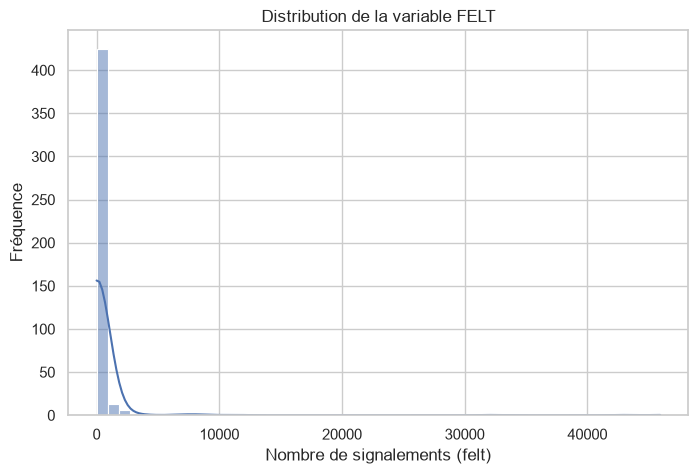

In [27]:
# ============================================================
# VISUALISATION DE LA DISTRIBUTION DE FELT
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_pager,
    x='felt',
    bins=50,
    kde=True
)

plt.title("Distribution de la variable FELT")
plt.xlabel("Nombre de signalements (felt)")
plt.ylabel("Fréquence")

plt.show()

**Interprétation du résultat :**  
L'histogramme montre une forte asymétrie vers la droite. Quelques valeurs très élevées écrasent la majorité des observations proches de zéro.

### 28. Transformation logarithmique de FELT

Je garde les grandes valeurs car elles peuvent être réelles, mais j'applique `log1p` pour réduire leur poids et obtenir une variable plus facile à utiliser dans le modèle.

In [28]:
# ============================================================
# TRANSFORMATION LOGARITHMIQUE DE FELT
# ============================================================

df_pager['felt_log'] = np.log1p(df_pager['felt'])

print("Statistiques de FELT original :")
print(df_pager['felt'].describe())

print("\nStatistiques de FELT après log1p :")
print(df_pager['felt_log'].describe())

Statistiques de FELT original :
count      453.000000
mean       481.796909
std       3417.311314
min          0.000000
25%          3.000000
50%         12.000000
75%         54.000000
max      45935.000000
Name: felt, dtype: float64

Statistiques de FELT après log1p :
count    453.000000
mean       2.912124
std        2.059555
min        0.000000
25%        1.386294
50%        2.564949
75%        4.007333
max       10.735004
Name: felt_log, dtype: float64


**Interprétation du résultat :**  
Après `log1p`, la variable `FELT` est beaucoup moins étalée. La transformation conserve l'information tout en réduisant l'influence des très grandes valeurs.

### 29. Imputation des valeurs manquantes

Je remplace les valeurs manquantes de CDI et de FELT transformé par leur médiane. La médiane est plus robuste que la moyenne pour ce type de données.

In [29]:
# ============================================================
# IMPUTATION DES VALEURS MANQUANTES PAR LA MÉDIANE
# ============================================================

cdi_median = df_pager['cdi'].median()
felt_log_median = df_pager['felt_log'].median()

print("Médiane CDI :", cdi_median)
print("Médiane FELT_LOG :", felt_log_median)

df_pager['cdi_imputed'] = df_pager['cdi'].fillna(cdi_median)
df_pager['felt_log_imputed'] = df_pager['felt_log'].fillna(felt_log_median)

print("\nValeurs manquantes après imputation :")
print(
    df_pager[
        ['cdi_imputed', 'felt_log_imputed']
    ].isnull().sum()
)

Médiane CDI : 4.1
Médiane FELT_LOG : 2.5649493574615367

Valeurs manquantes après imputation :
cdi_imputed         0
felt_log_imputed    0
dtype: int64


**Interprétation du résultat :**  
Après l'imputation par la médiane, `cdi_imputed` et `felt_log_imputed` ne contiennent plus aucune valeur manquante.

### 30. Analyse des corrélations

Je regarde les corrélations entre les variables explicatives pour vérifier si certaines apportent presque la même information.

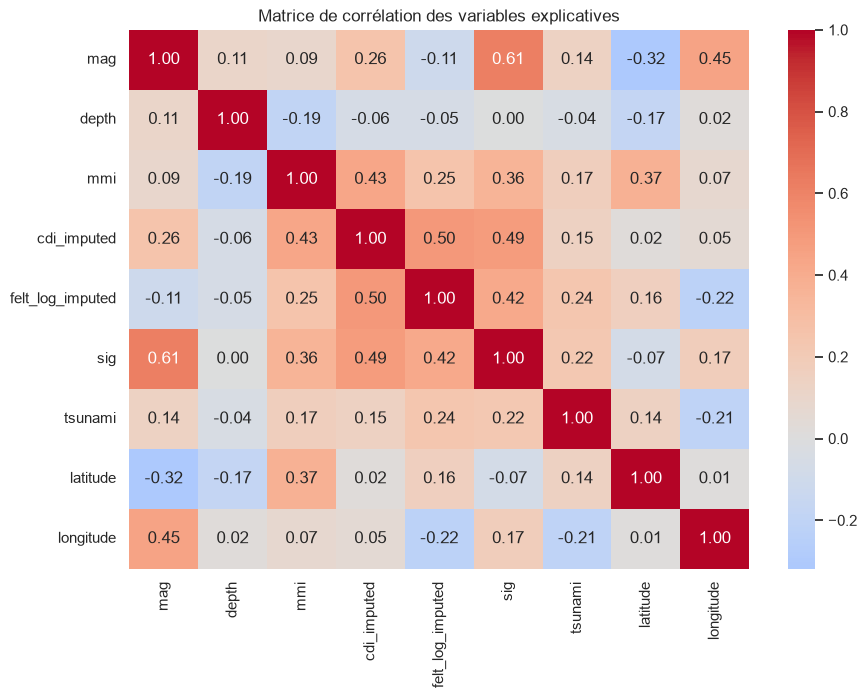

In [30]:
# ============================================================
# ANALYSE DES CORRÉLATIONS ENTRE LES VARIABLES X
# ============================================================

features_corr = [
    'mag',
    'depth',
    'mmi',
    'cdi_imputed',
    'felt_log_imputed',
    'sig',
    'tsunami',
    'latitude',
    'longitude'
]

correlation_matrix = df_pager[features_corr].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables explicatives")
plt.show()

**Interprétation du résultat :**  
Aucune corrélation n'est assez forte pour justifier la suppression immédiate d'une variable. `sig` et `mag` sont corrélées, mais pas au point d'être redondantes.

### 31. Définition de X et Y

Je définis maintenant les variables explicatives X et la cible Y. X contient neuf variables et Y contient le niveau de dommages.

In [31]:
# ============================================================
# DÉFINITION DES VARIABLES X ET Y
# ============================================================

features = [
    'mag',
    'depth',
    'mmi',
    'cdi_imputed',
    'felt_log_imputed',
    'sig',
    'tsunami',
    'latitude',
    'longitude'
]

X = df_pager[features].copy()
y = df_pager['Damage_Level'].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nVariables X :")
print(X.columns.tolist())

print("\nDistribution de Y :")
print(y.value_counts())

print("\nValeurs manquantes dans X :", X.isnull().sum().sum())

Dimensions de X : (904, 9)
Dimensions de y : (904,)

Variables X :
['mag', 'depth', 'mmi', 'cdi_imputed', 'felt_log_imputed', 'sig', 'tsunami', 'latitude', 'longitude']

Distribution de Y :
Damage_Level
Faible    865
Modéré     25
Sévère     14
Name: count, dtype: int64

Valeurs manquantes dans X : 0


**Interprétation du résultat :**  
Le jeu de données final contient **904 observations et 9 variables X**, avec `Damage_Level` comme Y. Il ne reste aucune valeur manquante dans X.

### 32. Séparation Train/Test

Je garde 80 % des données pour l'entraînement et 20 % pour le test. J'utilise `stratify=y` pour conserver au mieux la proportion des trois classes.

In [32]:
# ============================================================
# SÉPARATION DES DONNÉES — TRAIN / TEST
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nDistribution Y_train :")
print(y_train.value_counts())

print("\nDistribution Y_test :")
print(y_test.value_counts())

X_train : (723, 9)
X_test  : (181, 9)

Distribution Y_train :
Damage_Level
Faible    692
Modéré     20
Sévère     11
Name: count, dtype: int64

Distribution Y_test :
Damage_Level
Faible    173
Modéré      5
Sévère      3
Name: count, dtype: int64


**Interprétation du résultat :**  
La séparation donne **723 lignes pour l'entraînement et 181 pour le test**. La stratification conserve les trois classes dans les deux ensembles.

### 33. Normalisation des variables

KNN est sensible aux différences d'échelle entre les variables. J'apprends donc le `StandardScaler` uniquement sur les données d'entraînement, puis je l'applique au test.

In [33]:
# ============================================================
# NORMALISATION DES VARIABLES X
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensions X_train_scaled :", X_train_scaled.shape)
print("Dimensions X_test_scaled  :", X_test_scaled.shape)

print("\nMoyenne approximative du TRAIN après normalisation :")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nÉcart-type approximatif du TRAIN après normalisation :")
print(np.round(X_train_scaled.std(axis=0), 2))

Dimensions X_train_scaled : (723, 9)
Dimensions X_test_scaled  : (181, 9)

Moyenne approximative du TRAIN après normalisation :
[ 0.  0.  0. -0.  0.  0.  0. -0.  0.]

Écart-type approximatif du TRAIN après normalisation :
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Interprétation du résultat :**  
Après normalisation, les variables d'entraînement ont une moyenne proche de **0** et un écart-type proche de **1**. Elles sont donc sur une échelle comparable pour KNN.

### 34. Algorithme 1 — KNN

Je commence avec KNN en utilisant les données normalisées. Je regarde l'Accuracy, mais surtout le Recall de la classe `Sévère`.

In [34]:
# ============================================================
# ALGORITHME 1 — K-NEAREST NEIGHBORS (KNN)
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN :", round(accuracy_knn, 4))

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred_knn,
        labels=['Faible', 'Modéré', 'Sévère'],
        zero_division=0
    )
)

print("\nMatrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_knn,
        labels=['Faible', 'Modéré', 'Sévère']
    )
)

Accuracy KNN : 0.9613

Rapport de classification :
              precision    recall  f1-score   support

      Faible       0.97      0.99      0.98       173
      Modéré       0.50      0.20      0.29         5
      Sévère       1.00      0.33      0.50         3

    accuracy                           0.96       181
   macro avg       0.82      0.51      0.59       181
weighted avg       0.95      0.96      0.95       181


Matrice de confusion :
[[172   1   0]
 [  4   1   0]
 [  2   0   1]]


**Interprétation du résultat :**  
KNN obtient environ **96,1 % d'Accuracy**, mais il détecte seulement **1 cas Sévère sur 3**. Son Recall `Sévère` est donc faible, autour de **0,33**.

### 35. Algorithme 2 — Decision Tree

Je teste ensuite un arbre de décision. J'utilise `class_weight='balanced'` parce que les classes `Modéré` et `Sévère` sont beaucoup plus rares.

In [35]:
# ============================================================
# ALGORITHME 2 — DECISION TREE
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Accuracy Decision Tree :", round(accuracy_tree, 4))

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred_tree,
        labels=['Faible', 'Modéré', 'Sévère'],
        zero_division=0
    )
)

print("\nMatrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_tree,
        labels=['Faible', 'Modéré', 'Sévère']
    )
)

Accuracy Decision Tree : 0.9834

Rapport de classification :
              precision    recall  f1-score   support

      Faible       1.00      0.99      1.00       173
      Modéré       0.67      0.80      0.73         5
      Sévère       0.67      0.67      0.67         3

    accuracy                           0.98       181
   macro avg       0.78      0.82      0.80       181
weighted avg       0.99      0.98      0.98       181


Matrice de confusion :
[[172   1   0]
 [  0   4   1]
 [  0   1   2]]


**Interprétation du résultat :**  
Decision Tree améliore nettement les résultats : environ **98,3 % d'Accuracy** et un Recall `Sévère` de **0,67**.

### 36. Algorithme 3 — Random Forest

Je teste enfin Random Forest avec 200 arbres et un poids équilibré pour les classes.

In [36]:
# ============================================================
# ALGORITHME 3 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest :", round(accuracy_rf, 4))

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=['Faible', 'Modéré', 'Sévère'],
        zero_division=0
    )
)

print("\nMatrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_rf,
        labels=['Faible', 'Modéré', 'Sévère']
    )
)

Accuracy Random Forest : 0.989

Rapport de classification :
              precision    recall  f1-score   support

      Faible       1.00      0.99      1.00       173
      Modéré       0.71      1.00      0.83         5
      Sévère       1.00      0.67      0.80         3

    accuracy                           0.99       181
   macro avg       0.90      0.89      0.88       181
weighted avg       0.99      0.99      0.99       181


Matrice de confusion :
[[172   1   0]
 [  0   5   0]
 [  0   1   2]]


**Interprétation du résultat :**  
Random Forest obtient environ **98,9 % d'Accuracy**. Il détecte les **5 cas Modéré sur 5** et **2 cas Sévère sur 3**.

### 37. Comparaison des trois algorithmes

Je rassemble les résultats dans un seul tableau. Pour ce modèle, je donne une attention particulière au Recall et au F1 de la classe `Sévère`.

In [37]:
# ============================================================
# COMPARAISON DES TROIS ALGORITHMES
# ============================================================

results = pd.DataFrame({
    'Modèle': [
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision_Sévère': [
        precision_score(
            y_test, y_pred_knn,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        precision_score(
            y_test, y_pred_tree,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        precision_score(
            y_test, y_pred_rf,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0]
    ],

    'Recall_Sévère': [
        recall_score(
            y_test, y_pred_knn,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        recall_score(
            y_test, y_pred_tree,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        recall_score(
            y_test, y_pred_rf,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0]
    ],

    'F1_Sévère': [
        f1_score(
            y_test, y_pred_knn,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        f1_score(
            y_test, y_pred_tree,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0],

        f1_score(
            y_test, y_pred_rf,
            labels=['Sévère'],
            average=None,
            zero_division=0
        )[0]
    ]
})

results = results.round(3)

print("Comparaison des modèles :")
display(results)

Comparaison des modèles :


,Modèle,Accuracy,Precision_Sévère,Recall_Sévère,F1_Sévère
0,KNN,0.961,1.000,0.333,0.500
1,Decision Tree,0.983,0.667,0.667,0.667
2,Random Forest,0.989,1.000,0.667,0.800


**Interprétation du résultat :**  
Random Forest donne le meilleur résultat global. Decision Tree et Random Forest ont le même Recall `Sévère`, mais Random Forest possède une meilleure Accuracy et un meilleur F1 pour cette classe.

### 38. Sélection du modèle champion

Random Forest est retenu comme modèle champion. Il obtient la meilleure Accuracy globale et de bons résultats sur la classe `Sévère`.

In [38]:
# ============================================================
# SÉLECTION DU MODÈLE CHAMPION
# ============================================================

champion_model = random_forest
champion_name = "Random Forest"

print("MODÈLE CHAMPION :", champion_name)
print("Accuracy :", round(accuracy_rf, 3))
print(
    "Recall Sévère :",
    round(
        recall_score(
            y_test,
            y_pred_rf,
            labels=['Sévère'],
            average=None
        )[0],
        3
    )
)

MODÈLE CHAMPION : Random Forest
Accuracy : 0.989
Recall Sévère : 0.667


**Interprétation du résultat :**  
Le modèle champion retenu est donc **Random Forest**, avec une Accuracy d'environ **0,989** et un Recall `Sévère` d'environ **0,667**.

### 39. Matrice de confusion du champion

Je représente la matrice de confusion du Random Forest pour voir précisément les bonnes et les mauvaises classifications.

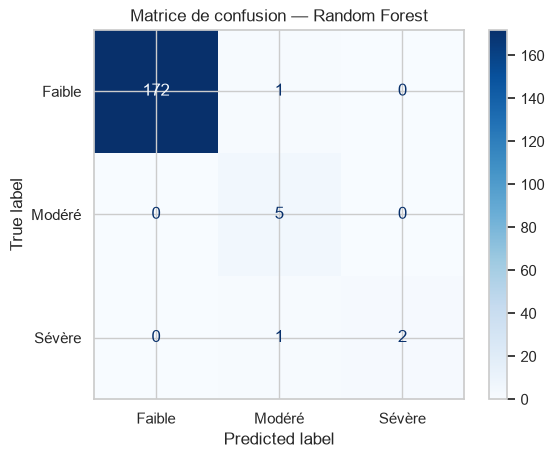

In [39]:
# ============================================================
# MATRICE DE CONFUSION — MODÈLE CHAMPION RANDOM FOREST
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

labels = ['Faible', 'Modéré', 'Sévère']

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=labels
)

disp.plot(cmap='Blues')

plt.title("Matrice de confusion — Random Forest")
plt.show()

**Interprétation du résultat :**  
La matrice montre que Random Forest classe correctement **172/173 Faible, 5/5 Modéré et 2/3 Sévère**. Le seul cas sévère manqué est classé `Modéré`, pas `Faible`.

### 40. Importance des variables

Je regarde quelles variables ont le plus influencé les décisions du Random Forest.

In [40]:
# ============================================================
# IMPORTANCE DES VARIABLES — RANDOM FOREST
# ============================================================

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Importance des variables :")
display(feature_importance)

Importance des variables :


,Variable,Importance
5,sig,0.332574
2,mmi,0.312859
3,cdi_imputed,0.101374
4,felt_log_imputed,0.076176
7,latitude,0.055560
8,longitude,0.053231
1,depth,0.034164
0,mag,0.031846
6,tsunami,0.002217


**Interprétation du résultat :**  
Les variables les plus importantes sont `sig` et `mmi`, suivies de `cdi_imputed` et `felt_log_imputed`.

### 41. Graphique de l'importance des variables

Je représente l'importance des variables sous forme de graphique pour faciliter l'interprétation.

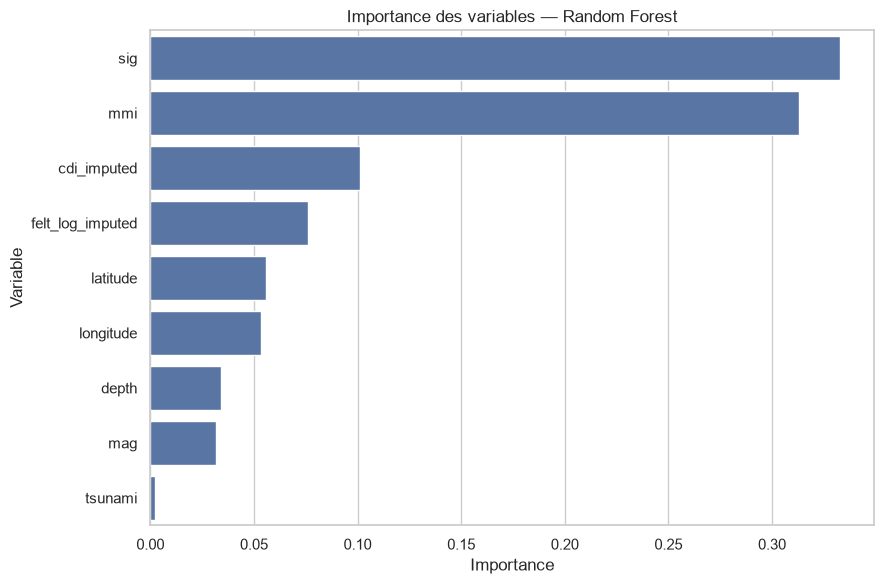

In [41]:
# ============================================================
# GRAPHIQUE DE L'IMPORTANCE DES VARIABLES
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Variable'
)

plt.title("Importance des variables — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

**Interprétation du résultat :**  
Le graphique confirme que `sig` et `mmi` dominent clairement les autres variables dans les décisions du Random Forest.

### 42. Sauvegarde du dataset préparé

Je sauvegarde le sous-ensemble PAGER avec la cible et les variables prétraitées dans un nouveau fichier. Le fichier source n'est pas modifié.

In [42]:
# ============================================================
# SAUVEGARDE DU DATASET PRÉTRAITÉ — MODEL DAMAGE
# ============================================================

output_path = os.path.join(
    "..",
    "data",
    "usgs_damage_processed_2025.csv"
)

df_pager.to_csv(
    output_path,
    index=False
)

print("Dataset sauvegardé avec succès :")
print(output_path)

print("\nNombre de lignes :", df_pager.shape[0])
print("Nombre de colonnes :", df_pager.shape[1])

Dataset sauvegardé avec succès :
..\data\usgs_damage_processed_2025.csv

Nombre de lignes : 904
Nombre de colonnes : 39


**Interprétation du résultat :**  
Le dataset préparé est sauvegardé dans un fichier séparé avec **904 lignes**. Le fichier source reste inchangé.

### 43. Sauvegarde du modèle champion

Je sauvegarde le Random Forest pour pouvoir le réutiliser plus tard dans l'API ou le dashboard sans devoir l'entraîner à nouveau.

In [43]:
# ============================================================
# SAUVEGARDE DU MODÈLE CHAMPION
# ============================================================

model_path = os.path.join(
    "..",
    "models",
    "damage_random_forest.joblib"
)

joblib.dump(
    champion_model,
    model_path
)

print("Modèle sauvegardé avec succès :")
print(model_path)

Modèle sauvegardé avec succès :
..\models\damage_random_forest.joblib


**Interprétation du résultat :**  
Le modèle Random Forest entraîné est maintenant sauvegardé et pourra être chargé plus tard sans refaire l'entraînement.

### 44. Sauvegarde du scaler

Je sauvegarde aussi le scaler utilisé pour KNN afin de garder tout le prétraitement reproductible.

In [44]:
# ============================================================
# SAUVEGARDE DU SCALER
# ============================================================

scaler_path = os.path.join(
    "..",
    "models",
    "damage_scaler.joblib"
)

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler sauvegardé avec succès :")
print(scaler_path)

Scaler sauvegardé avec succès :
..\models\damage_scaler.joblib


**Interprétation du résultat :**  
Le scaler est également sauvegardé afin de pouvoir reproduire le même prétraitement lorsque KNN ou une autre étape normalisée sera réutilisée.

## Résultat final

Les trois modèles testés sont KNN, Decision Tree et Random Forest.

Dans nos résultats, Random Forest est le modèle champion avec une Accuracy d'environ **98,9 %** et un Recall d'environ **0,667** pour la classe `Sévère`.

La matrice de confusion montre que 2 des 3 cas sévères du jeu de test sont correctement détectés et que le troisième est classé `Modéré`, pas `Faible`.

Les variables les plus importantes sont principalement `sig` et `mmi`.